# Homework 2

### Deadline: Tuesday 20 May 2025 (by 19h00)

### Credits: 20 points


## Instructions:

- The homework is **individual**. Please include your name in the notebook.

- **Please send your compressed tar file with the following tree scheme:**

```
homework2.tar
    
    pdediffusion
    ├── metalconduction.ipynb
    ├── metalconduction.py     
    └── outputfolder
```

## Name: Males-Araujo Yorlan

## 1. Thermodynamics and Heat Conduction (12 points)

Please include your solutions to this problem within a single python notebook file: **metalconduction.ipynb**

Use appropriate numerical algorithms to study how the temperature profile in a heated metal wire evolves in time, under different initial and boundary conditions. For this, you need to numerically solve the 1D heat equation:

$$\frac{\partial T}{\partial t}=\alpha\frac{\partial^2 T}{\partial x^2}$$

where $T=T(x, t)$ describes the temperature of the metal, $x$ is position, $t$ is time, and $\alpha$ is the thermal diffusivity of the metal. We will consider the following metals:

| Metal      | $\alpha$ $\left(\frac{\text{mm}^2}{\text{s}}\right)$ |
|------------|--------------------------|
| Copper     | 111                      |
| Iron       | 23                       |
| Aluminum   | 97                       |
| Brass      | 34                       |
| Steel      | 18                       |
| Zinc       | 63                       |
| Lead       | 22                       |
| Titanium   | 9.8                      |

Assume that the metal wire has a length of $20\,\rm cm$, and choose the wire midpoint as the origin for the domain.

### Code design:

Organise your code using **python classes** and carry out the following tasks:

##### **(a)** Place the metals and diffusivities in a python dictionary.

We transformed from $\rm mm^2/s$ to $\rm cm^2/s$ for convenience.

##### **(bx2)** Create a simulation initialisation routine where e.g. the mesh, the initial conditions, and the boundary conditions are all set up.

Consider two types of **initial conditions**:

- **Smooth**, which sets the initial temperature profile in degrees Celsius to be:

$$T(x, 0)= 175 - 50\cos\left(\frac{\pi x}{5}\right) - x^2$$

where $x$ is in units of $\rm cm$. 

- **Noisy**, which adds some noise $f(x)$ with amplitude $\beta$ to the initial condition:

$$T(x, 0)= 175 - 50\cos\left(\frac{\pi x}{5}\right) - x^2 + \beta\,f(x)\,g(x)$$

Note that you need to find an appropriate apodisation function $g(x)$ so that the initial boundary conditions remain fixed at $25\,\rm C$. Similarly, a default amplitude for the noise function can be set to be less than a hundredth of the peak temperature value. 

Also, consider two types of **boundary conditions**:

- **Fixed**, which keep the temperatures at the edges of the metal wire fixed at a temperature of $25\,\rm C$. 
    
- **Varying**, which assume that the boundaries cannot be kept constant (because of e.g. a faulty cooling system). Instead they also evolve in time according to the following functions:

    $T(+10\,{\rm cm}, t) = 25 + 0.12\,t$

    $T(-10\,{\rm cm}, t) = 25 + 0.27\,t$

##### **(cx3)** Construct a Crank-Nicolson algorithm to simulate **the evolution of an initial temperature profile** and find the **time in seconds at which thermal equilibrium is reached** in an input metal wire (from the dictionary). **Hint:** You need to define some criteria to determine thermal equilibrium.

Both (b) and (c) were implemented in a single class called [].

### Smooth-Fixed Simulations:

##### **(d)** Pick **two metal wires** from the dictionary and run both simulations using your Crank-Nicolson algorithm. To compare the results, make a high-quality, 2-column figure showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of each metal wire versus $x$ at a few selected times.

We chose Copper and Titanium because they have the highest and lowest diffusivity, respectively.

In [36]:
# My code
from metalconduction import SingleSolver

# Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Objects
copper = SingleSolver(metal = 'Copper')
titanm = SingleSolver(metal = 'Titanium')

In [2]:
# Parameters
dt      = 0.2
dx      = 0.05
t_max   = 700.0

In [4]:
# Integrate
x_copper, t_copper, T_copper, eq_cop, eq_cop_time = copper.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

x_titanm, t_titanm, T_titanm, eq_tit, eq_tit_time = titanm.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

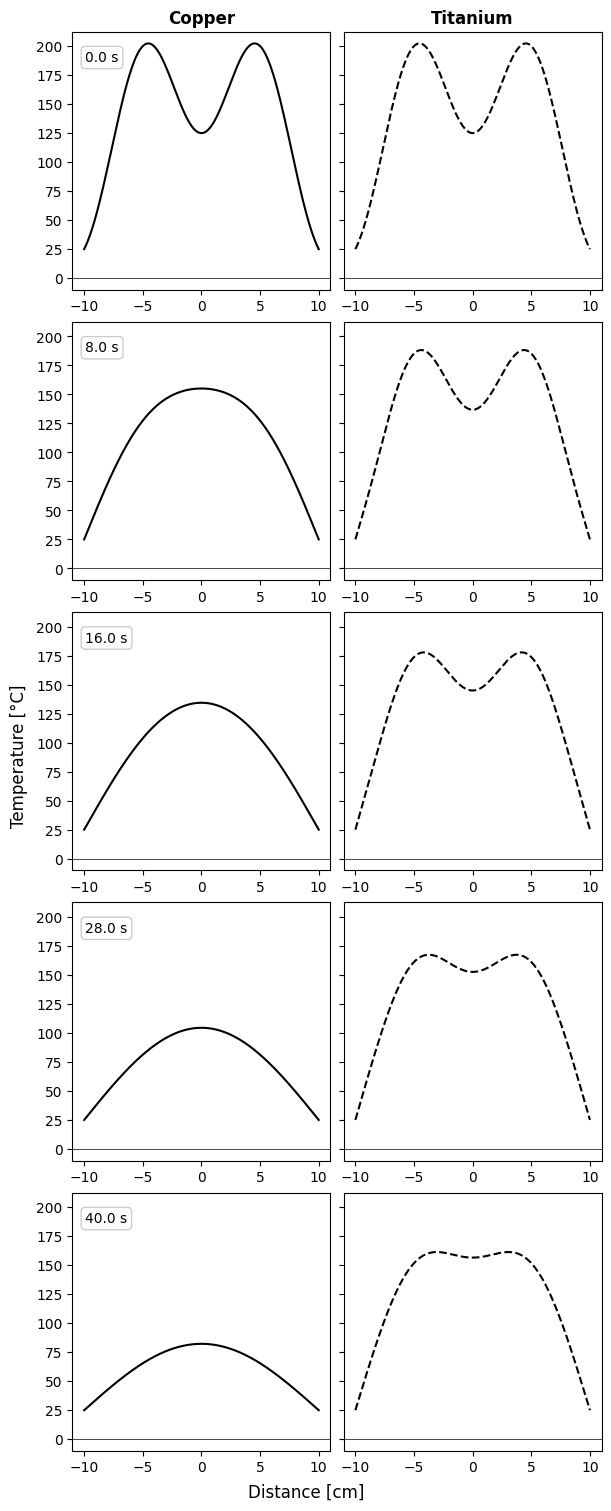

In [5]:
# Plot
fig, axs = plt.subplots(5, 2, figsize=(6, 15), sharey = True, constrained_layout = True)

# Labels
fig.supxlabel('Distance [cm]', fontsize = 12)
fig.supylabel('Temperature [°C]', fontsize = 12)

# Metals
axs[0, 0].set_title('Copper', fontweight = 'bold', fontsize = 12)
axs[0, 1].set_title('Titanium', fontweight = 'bold', fontsize = 12)
 
# Snapshots
time_indices = [0, 40, 80, 140, 200]

# Loop
for i, idx in enumerate(time_indices):

    # Solutions
    axs[i, 0].plot(x_copper, T_copper[:, idx], color = "k")
    axs[i, 1].plot(x_titanm, T_titanm[:, idx], ls ='--', color = "k")

    axs[i, 0].axhline(0, color = "k", lw = 0.5)
    axs[i, 1].axhline(0, color = "k", lw = 0.5)
    
    # Time (just one because they're the same)
    axs[i, 0].text(0.05, 0.9, f'{t_copper[idx]:.1f} s', 
                   transform = axs[i, 0].transAxes, fontsize = 10,
                   va = 'center', bbox = dict(facecolor = 'w', alpha = 0.2, boxstyle='round'))
    
    axs[i, 1].tick_params(labelleft=False)

plt.show()

In [51]:
# Thermal equilibrium
print("--" * 20)
print("Thermal equilibrium check")
print("--" * 20)
if all([eq_cop, eq_tit]):
    print("Thermal equilibrium reached!")
    print(f"Copper: {eq_cop:.2f} s")
    print(f"Titanium: {eq_tit:.2f} s")
else:
    print("Thermal equilibrium NOT reached!")
print("--" * 20)

----------------------------------------
Thermal equilibrium check
----------------------------------------
Thermal equilibrium reached!
Copper: 1.00 s
Titanium: 1.00 s
----------------------------------------


As expected, Copper decreases its temperature faster than Titanium because it has a higher diffusivity.

### Smooth-Fixed versus Noisy-Fixed Simulations:

##### **(e)** Study heat diffusion only in the Zinc wire considering **smooth versus noisy initial conditions** with noise of 3 different amplitudes. To compare the results, make a high-quality, 4-panel figure (with 2 columns and 2 rows) showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of the Zinc metal wire versus $x$ at a few selected times, under different initial conditions (smooth vs. 3 noisy cases).

In [6]:
# Zinc object
zinc = SingleSolver(metal = 'Zinc')

In [7]:
# Smooth
x_smooth, t_smooth, T_smooth, eq_smooth, eq_smooth_time = zinc.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

In [8]:
# Noises
large_noise  = 0.1
medium_noise = 0.05
small_noise  = 0.01

# Large noise
x_large, t_large, T_large, eq_large, eq_large_time = zinc.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Noisy",
    bc_type = "Fixed",
    noise_factor = large_noise
)

# Medium noise
x_medium, t_medium, T_medium, eq_medium, eq_medium_time = zinc.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Noisy",
    bc_type = "Fixed",
    noise_factor = medium_noise
)

# Small noise
x_small, t_small, T_small, eq_small, eq_small_time = zinc.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Noisy",
    bc_type = "Fixed",
    noise_factor = small_noise
)

In [23]:
# Indices
indices = [0, 20, 50, 100, 150, 200, 400, 800, 1000, 1500, 2000, 3000]

# Colors
n_plots = len(indices)
R = np.linspace(1, 0, n_plots)
G = 0
B = np.linspace(0, 1, n_plots)

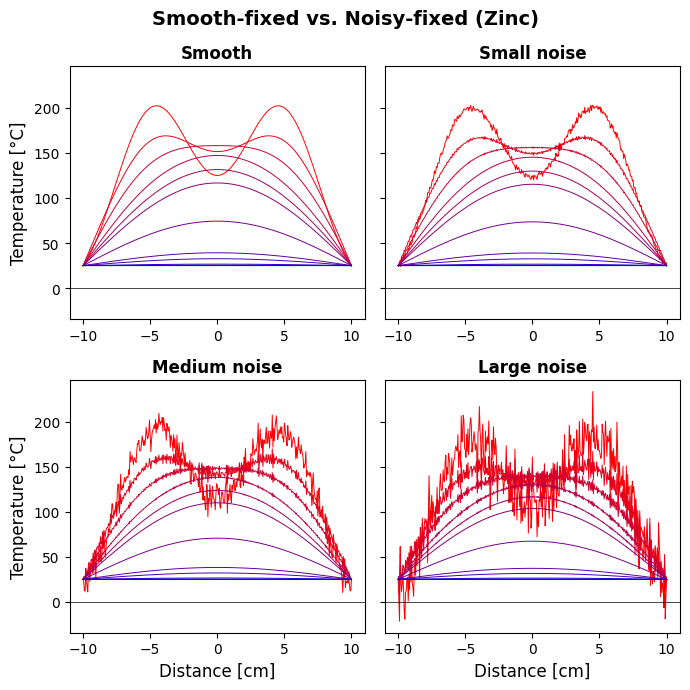

In [45]:
# Plot
fig, axs = plt.subplots(2, 2, figsize=(7, 7), sharey = True)

# Title
fig.suptitle('Smooth-fixed vs. Noisy-fixed (Zinc)', fontweight = 'bold', fontsize = 14)

# Smooth
for i, idx in enumerate(indices):

    # Color
    color = [R[i], G, B[i]]

    # Plots
    axs[0, 0].plot(x_smooth, T_smooth[:, idx], color = color, lw = 0.7)
    axs[0, 1].plot(x_small, T_small[:, idx], color = color, lw = 0.7)
    axs[1, 0].plot(x_medium, T_medium[:, idx], color = color, lw = 0.7)
    axs[1, 1].plot(x_large, T_large[:, idx], color = color, lw = 0.7)

# Lines at 0
axs[0, 0].axhline(0, color = "k", lw = 0.5)
axs[0, 1].axhline(0, color = "k", lw = 0.5)
axs[1, 0].axhline(0, color = "k", lw = 0.5)
axs[1, 1].axhline(0, color = "k", lw = 0.5)

# Titles and labels
axs[0, 0].set_title('Smooth', fontweight = 'bold', fontsize = 12)
axs[0, 1].set_title('Small noise', fontweight = 'bold', fontsize = 12)
axs[1, 0].set_title('Medium noise', fontweight = 'bold', fontsize = 12)
axs[1, 1].set_title('Large noise', fontweight = 'bold', fontsize = 12)

axs[0, 0].set_ylabel('Temperature [°C]', fontsize = 12)
axs[1, 0].set_ylabel('Temperature [°C]', fontsize = 12)
axs[1, 0].set_xlabel('Distance [cm]', fontsize = 12)
axs[1, 1].set_xlabel('Distance [cm]', fontsize = 12)

# Show
plt.tight_layout()
plt.show()

In [46]:
# Thermal equilibrium check
print("--" * 20)
print("Thermal equilibrium check")
print("--" * 20)
if all([eq_smooth, eq_large, eq_medium, eq_small]):
    print("Thermal equilibrium reached!")
    print(f"Smooth: {eq_smooth_time:.2f} s")
    print(f"Large noise: {eq_large_time:.2f} s")
    print(f"Medium noise: {eq_medium_time:.2f} s")
    print(f"Small noise: {eq_small_time:.2f} s")
else:
    print("Thermal equilibrium NOT reached!")
print("--" * 20)

----------------------------------------
Thermal equilibrium check
----------------------------------------
Thermal equilibrium reached!
Smooth: 226.60 s
Large noise: 216.80 s
Medium noise: 221.60 s
Small noise: 225.60 s
----------------------------------------


All the noise is eventually smoothed out, resulting in similar temperature profiles and thermal equilibrium being reached at nearly the same time.

### Smooth-Fixed versus Smooth-Varying Simulations:

##### **(f)** Study heat diffusion only in the Aluminum wire considering **fixed versus varying boundary conditions**. To compare the results, make a high-quality, 2-column figure showing the time evolution of the 1D temperature profile, $T=T(x, t)$, of the Aluminum metal wire versus $x$ at a few selected times, under different boundary conditions.

In [48]:
# Object
alum = SingleSolver(metal = 'Aluminum')

In [49]:
# Integrate
x_fixed, t_fixed, T_fixed, eq_fixed, eq_fixed_time = alum.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

x_varying, t_varying, T_varying, eq_varying, eq_varying_time = alum.integrate(
    dt = dt,
    dx = dx,
    t_max = t_max,
    ic_type = "Smooth",
    bc_type = "Varying"
)

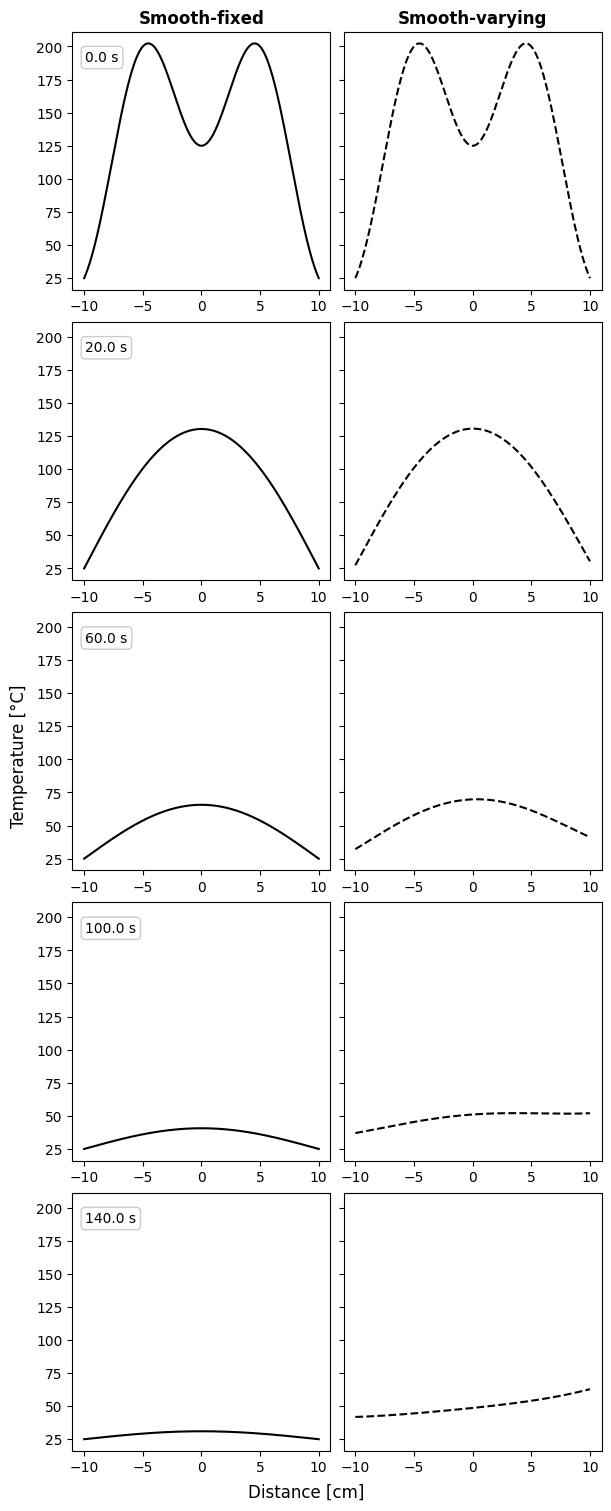

In [54]:
# Plot
fig, axs = plt.subplots(5, 2, figsize=(6, 15), sharey = True, constrained_layout = True)

# Labels
fig.supxlabel('Distance [cm]', fontsize = 12)
fig.supylabel('Temperature [°C]', fontsize = 12)

# Metals
axs[0, 0].set_title('Smooth-fixed', fontweight = 'bold', fontsize = 12)
axs[0, 1].set_title('Smooth-varying', fontweight = 'bold', fontsize = 12)
 
# Snapshots
time_indices = [0, 100, 300, 500, 700]

# Loop over time
for i, idx in enumerate(time_indices):

    # Solutions
    axs[i, 0].plot(x_fixed, T_fixed[:, idx], color = "k")
    axs[i, 1].plot(x_varying, T_varying[:, idx], ls ='--', color = "k")
    
    # Time
    axs[i, 0].text(0.05, 0.9, f'{t_fixed[idx]:.1f} s', 
                   transform = axs[i, 0].transAxes, fontsize = 10,
                   va = 'center', bbox = dict(facecolor = 'w', alpha = 0.2, boxstyle='round'))
    
    axs[i, 1].tick_params(labelleft=False)

plt.show()

### Analysis:

##### **(g)** Can we use explicit or FFT methods to solve this problem? Explain.

##### **(h)** Does the input noise amplitude change the time at which thermal equilibrium is reached or not? Why?

##### **(i)** What is the effect of a faulty cooling system on the temperature profile?

## 2. Joblib Parallelisation (8 points)

Consider the same statement provided in problem 1. All code should be organised in **python classes**.

### Parallelisation with joblib:

**(a)** Imagine we wish to run several simulations in parallel for the metals included in the dictionary. Within the **metalconduction.ipynb** notebook, create a routine that uses ```joblib``` to parallelise the simulation executions in $n$ CPUs.

Done. Multiple simulations can be run in serial or parallel with the class `MultipleSolver`. 

**(b)** Test your implementation by running $2$ simulations ($1$ for Iron and $1$ for Lead) first in serial and then in parallel (simultaneously). For the serial run, $n=1$ CPU core. For the parallel run, $n=2$ CPU cores. The time should go down. **Hint:** You need to add time stamps to quantify and return log files with the execution times. 

In [1]:
# Import
from metalconduction import MultipleSolver

In [18]:
# Metals (we added two metals in order to test with 4 cores too)
metals = ['Iron', 'Lead', 'Copper', 'Brass']

# Objects
paral4 = MultipleSolver(
    metals = metals,
    parallel = True,
    n_jobs = 4
)
paral2 = MultipleSolver(
    metals = metals,
    parallel = True,
    n_jobs = 2
)
serial = MultipleSolver(
    metals = metals,
    parallel = False
)

In [24]:
# Integrate
print("**" * 32)

# New dx
dx = 0.02

results_paral4, time_paral4 = paral4.integrate(
    dt = dt,
    dx = dx,
    t_max = 100,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

print("**" * 32)

results_paral2, time_paral2 = paral2.integrate(
    dt = dt,
    dx = dx,
    t_max = 100,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

print("**" * 32)

results_serial, time_serial = serial.integrate(
    dt = dt,
    dx = dx,
    t_max = 100,
    ic_type = "Smooth",
    bc_type = "Fixed"
)

print("**" * 32)

****************************************************************
> Metals to be integrated:
  - Iron [0.23 cm²/s]
  - Lead [0.22 cm²/s]
  - Copper [1.11 cm²/s]
  - Brass [0.34 cm²/s]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                PARALLEL INTEGRATION STARTED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
> Number of jobs: 4.

> Reached thermal equilibrium:
  - Iron: False, 100.00 s
  - Lead: False, 100.00 s
  - Copper: False, 100.00 s
  - Brass: False, 100.00 s

> Total integration time: 40.96 s.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                PARALLEL INTEGRATION ENDED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
****************************************************************
> Metals to be integrated:
  - Iron [0.23 cm²/s]
  - Lead [0.22 cm²/s]
  - Copper [1.11 cm²/s]
  - Brass [0.34 cm²/s]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                PARALLEL INTEGRATION STARTED


**(c)** Make a scaling plot showing (serial and parallel) execution times in the $Y$ axis versus the number of CPU cores ($n$) in the $X$ axis.

In [25]:
# CPUs array
cpus = np.array([1, 2, 4])

# Times
times = np.array([time_serial, time_paral2, time_paral4])

# Ideal time
ideal_time = time_serial / cpus

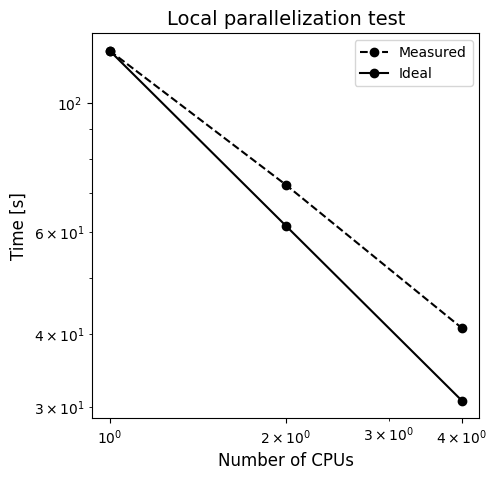

In [35]:
# Plot
plt.subplots(figsize=(5, 5))

plt.plot(cpus, times, marker = 'o', color = 'k', ls = '--', label = 'Measured')
plt.plot(cpus, ideal_time, marker = 'o', color = 'k', label = 'Ideal')

plt.loglog()

plt.xlabel('Number of CPUs', fontsize = 12)
plt.ylabel('Time [s]', fontsize = 12)
plt.title('Local parallelization test', fontsize = 14)

plt.xticks(cpus)
plt.legend()

plt.show()

True scaling is not achieved, but I wouldn't say it's bad either.

### HPC execution:

**(d)** Convert your notebook code into a script called: **metalconduction.py**. Then, copy it to the CEDIA cluster (or the Imbabura cluster), reserve computing resources (e.g. $8$ CPU cores), then run your code in serial and parallel for all the $8$ metals at increasing $n$ (e.g. $1$, $2$, $4$, $8$ CPU cores). Export log files from each run, so that the thermal equilibrium times and simulation run times can be analysed later. Include the log files and all your SLURM job scripts in the **outputfolder.**

---
I decided to write all the code in such file from the beginning, so I didn't need to convert it. 

---

**(e)** Within the **metalconduction.ipynb** notebook, create a routine to open the log files produced by the serial run and all the different parallel runs on the HPC cluster.

We ran the same simulation with different numbers of CPU cores a number of $5$ times, and the results were consistent. 

In [43]:
import os
import glob
import re

In [ ]:
def parse_log_files(base_folder="outputfolder"):
    
    data = []
    
    # Find all log files matching pattern
    for log_file in glob.glob(f"{base_folder}/run_*/azula.*.log"):
        # Extract run number
        run_id = int(log_file.split('/')[1].split('_')[1])
        
        # Extract core count from filename
        n_jobs = int(log_file.split('/')[-1].split('.')[1])
        
        # Get execution time
        with open(log_file, 'r') as f:
            content = f.read()
            if match := re.search(r"Total integration time: (\d+\.\d+)", content):
                time = float(match.group(1))
                data.append([run_id, n_jobs, time])
    
    # Create DataFrame
    return pd.DataFrame(data, columns=['run_id', 'n_jobs', 'time'])

# Test the function
df = parse_log_files()
df

,run_id,n_jobs,time
0,2,8,2.81
1,2,4,4.50
2,2,2,8.58
3,2,1,16.06
4,3,8,2.82
5,3,4,4.56
6,3,2,8.38
7,3,1,15.37
8,1,8,2.91
9,1,4,5.54


**(f)** Make a new scaling plot for the HPC cluster showing the executions times on the Y-axis and number of cores on the X-axis. Display also the **Amdahl's law**. 

In [53]:
# Time average by n_jobs
time_avg = df.groupby('n_jobs')['time'].mean().reset_index()
time_std = df.groupby('n_jobs')['time'].std().reset_index()

avg_cedia = np.array(time_avg['time'])
std_cedia = np.array(time_std['time'])
jobs_cedia = np.array(time_avg['n_jobs'])

In [48]:
# Ideal time
ideal_time = avg_cedia[0] / jobs_cedia

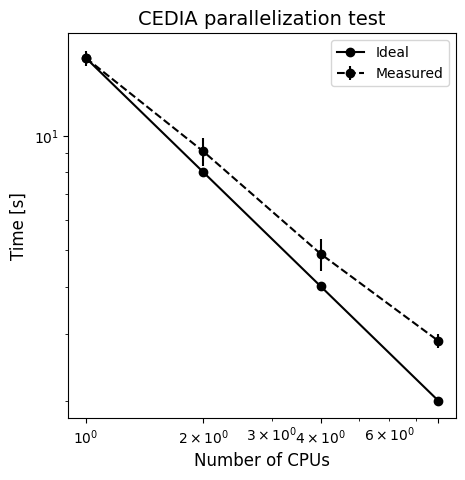

In [56]:
# Plot
plt.subplots(figsize=(5, 5))
plt.errorbar(jobs_cedia, avg_cedia, yerr=std_cedia, marker='o', color='k', ls='--', label='Measured')
plt.plot(jobs_cedia, ideal_time, marker='o', color='k', label='Ideal')
plt.loglog()
plt.xlabel('Number of CPUs', fontsize = 12)
plt.ylabel('Time [s]', fontsize = 12)
plt.title('CEDIA parallelization test', fontsize = 14)
plt.xticks(jobs_cedia)
plt.legend()
plt.show()

### Analysis:

**(g)** Compare the Amdahl's law to your results and comment on the findings (e.g. does your parallelisation follow Amdahl's law? Why yes or no?)



**(h)** Make a plot showing the thermal equilibrium times versus diffusivities. Do the different thermal equilibrium times for dstinct metals influence how ```joblib``` handles parallelisation?
